In [38]:
import torch
import numpy as np
from PIL import Image

import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models

device = "cuda" if torch.cuda.is_available() else "cpu"

# VGG16 pretrained on ImageNet
weights = models.VGG16_Weights.IMAGENET1K_V1
model = models.vgg16(weights=weights).to(device)
model.eval()


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [39]:
# load images
import os
datapath = '../data'
filename = 'miguel_passive8x4.mat'
filepath = os.path.join(datapath, filename)
# load matlab mat file
from scipy.io import loadmat
img_mat = loadmat(filepath)
img = img_mat['img'].astype(np.float32)
images_gray = np.transpose(img, (2, 0, 1))
print('img:', images_gray.shape, images_gray.min(), images_gray.max())
print("num images:", len(images_gray))
# each 4 images belong to the same category
img_class = np.repeat(np.arange(len(images_gray) // 4), 4)
print("img_class:", img_class)

img: (32, 150, 600) 0.0 255.0
num images: 32
img_class: [0 0 0 0 1 1 1 1 2 2 2 2 3 3 3 3 4 4 4 4 5 5 5 5 6 6 6 6 7 7 7 7]


In [40]:
images_rgb = []
for i in range(len(images_gray)):
    im = images_gray[i]

    im = Image.fromarray(im.astype(np.uint8))
    
    # grayscale -> RGB (repeat channels)
    im = im.convert("RGB")

    images_rgb.append(im)

print("prepared images_rgb:", len(images_rgb))
print("example size/mode:", images_rgb[0].size, images_rgb[0].mode)

prepared images_rgb: 32
example size/mode: (600, 150) RGB


In [41]:
# normalize 
mean = (0.485, 0.456, 0.406)
std  = (0.229, 0.224, 0.225)

to_tensor = T.Compose([
    T.Resize((64, 264)), 
    T.ToTensor(),
    T.Normalize(mean=mean, std=std),
])

# (B,3,H,W)
x = torch.stack([to_tensor(im) for im in images_rgb], dim=0).to(device)
print("input tensor:", x.shape, x.dtype)

features = model.features

# Identify MaxPool indices (these separate blocks)
maxpool_idxs = [i for i, m in enumerate(features) if isinstance(m, nn.MaxPool2d)]
print("MaxPool indices:", maxpool_idxs)

block_outputs_maps = []   # list of (B,C,H,W) tensors (on GPU)
block_outputs_pooled = [] # list of (B,C) pooled vectors (on GPU)

cur = x
start = 0
for bi, mp_i in enumerate(maxpool_idxs):
    for j in range(start, mp_i):
        cur = features[j](cur)
        
    block_outputs_maps.append(cur)
    pooled = torch.mean(cur, dim=(2,3))  # global average pool -> (B,C*H*W)
    block_outputs_pooled.append(pooled)

    # now apply the maxpool to move to next block input
    cur = features[mp_i](cur)
    start = mp_i + 1

print("Num blocks:", len(block_outputs_pooled))
for i, p in enumerate(block_outputs_pooled, 1):
    print(f"Block {i}: pooled shape={tuple(p.shape)}, min={p.min().item():.4f}, max={p.max().item():.4f}")


input tensor: torch.Size([32, 3, 64, 264]) torch.float32
MaxPool indices: [4, 9, 16, 23, 30]
Num blocks: 5
Block 1: pooled shape=(32, 64), min=0.0001, max=1.7723
Block 2: pooled shape=(32, 128), min=0.0044, max=5.0440
Block 3: pooled shape=(32, 256), min=0.0000, max=26.3364
Block 4: pooled shape=(32, 512), min=0.0000, max=18.0534
Block 5: pooled shape=(32, 512), min=0.0000, max=9.0453


In [42]:
# check the range of pooled features for each VGG16 block
for bi, pooled in enumerate(block_outputs_pooled, 1):
    print(f"Block {bi}: shape={tuple(pooled.shape)}, min={pooled.min().item():.4f}, max={pooled.max().item():.4f}")


Block 1: shape=(32, 64), min=0.0001, max=1.7723
Block 2: shape=(32, 128), min=0.0044, max=5.0440
Block 3: shape=(32, 256), min=0.0000, max=26.3364
Block 4: shape=(32, 512), min=0.0000, max=18.0534
Block 5: shape=(32, 512), min=0.0000, max=9.0453


In [43]:
# save
pooled_block_features = [t.detach().cpu().numpy() for t in block_outputs_pooled]

os.makedirs("outputs", exist_ok=True)

pooled_obj = np.empty(len(pooled_block_features), dtype=object)
for i, arr in enumerate(pooled_block_features):
    pooled_obj[i] = arr

np.save("outputs/vgg16_pooled_features.npy", pooled_obj, allow_pickle=True)
print("saved:", "outputs/vgg16_pooled_features.npy")

saved: outputs/vgg16_pooled_features.npy


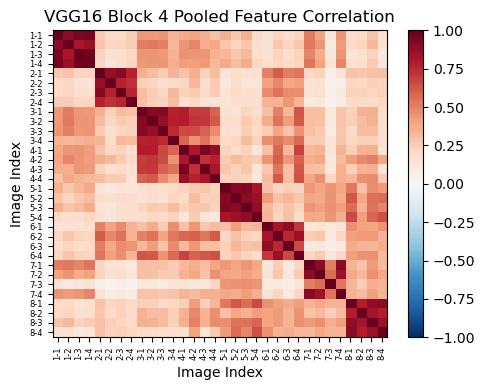

In [45]:
# correlation matrix for a chosen layer
import matplotlib.pyplot as plt
reps = pooled_block_features[-1]  # example: block 3 pooled features (B, C)

C = np.corrcoef(reps)

plt.figure(figsize=(5,4))
plt.imshow(C, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.title(f"VGG16 Block 4 Pooled Feature Correlation")
plt.xlabel("Image Index")
plt.ylabel("Image Index")
plt.xticks(ticks=np.arange(len(images_rgb)), labels=[f"{i+1}-{j+1}" for i in range(len(images_rgb) // 4) for j in range(4)], rotation=90, fontsize=6)
plt.yticks(ticks=np.arange(len(images_rgb)), labels=[f"{i+1}-{j+1}" for i in range(len(images_rgb) // 4) for j in range(4)], rotation=0, fontsize=6)
plt.colorbar()
plt.tight_layout()
plt.show()


/tmp/ipykernel_2907655/615472509.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


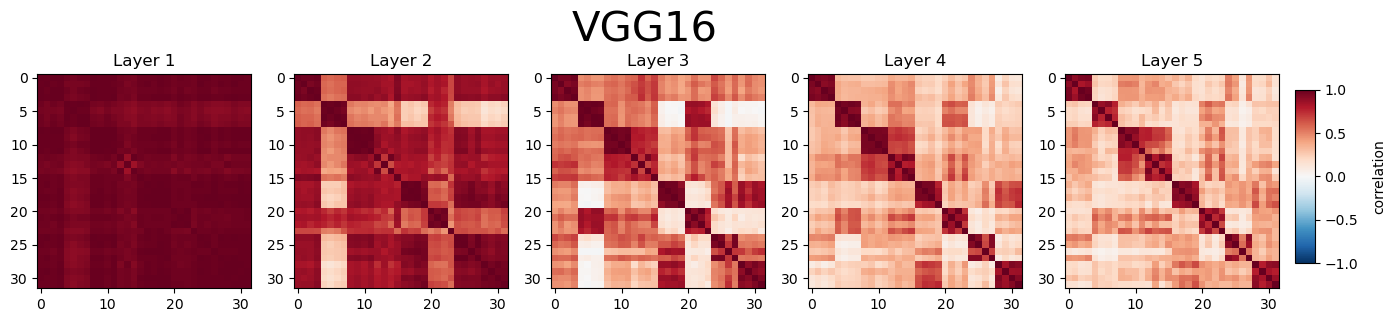

In [32]:
# visualize the rcm for different layers
layers = [f"Block {i+1}" for i in range(len(pooled_block_features))]
nlayers = len(layers)
fig, axes = plt.subplots(1, nlayers, figsize=(2*nlayers+3, 3))
axes = axes.ravel()
for li in range(nlayers):
    reps = pooled_block_features[li]
    C = np.corrcoef(reps)
    img = axes[li].imshow(C, cmap='RdBu_r', vmin=-1, vmax=1)
    axes[li].set_title(f"Layer {li+1}")
plt.suptitle("VGG16", fontsize=30)
# add a colorbar outside the last plot, but keep the last image the same size as others
# add code

# get position of last axis

pos = axes[-1].get_position()
cax = fig.add_axes([pos.x1 + 0.1, pos.y0-0.07, 0.015, pos.height])

cbar = fig.colorbar(img, cax=cax)
cbar.set_label('correlation', rotation=90, labelpad=10)
plt.tight_layout()
# save the figure
plt.savefig("../figures/vgg_corr_matrix.png", dpi=300, bbox_inches='tight')

plt.show()